In [31]:
import pandas as pd
from explainability_utils import *
from PIL import Image
from torchvision import transforms
from torch.utils.data import DataLoader
import h5py

sys.path.append(os.path.abspath("../training"))
from training_utils import CNN2D, SpectraDataset_s, SpectraDataset_p

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
pl.seed_everything(SEED)

Seed set to 42


42

In [25]:
output_path = "temporal_shap"
os.makedirs(output_path, exist_ok=True)
MAX_EVALS = 5000
base_path = r'..\preprocessed_dset_1'
f_t_range_64_path = os.path.join(base_path, 'sp_64', "f_t_range.npy")
tf64 = np.load(f_t_range_64_path)

ft = [tf64[:2], tf64[2:]]

# Setting for the datasets
mean_64, std_64 = spectra_stats(os.path.join(base_path, 'sp_64', "train"))

transform_64 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_64, std=std_64)
])

(..\preprocessed_dset_1\sp_64\train) Mean: [0.67176665 0.65817659 0.6412554 ], Std: [0.1186761  0.12021562 0.11939131] (calculated and saved)


#### Week division

In [3]:
# Load the features and metadata CSV files
df = pd.read_csv(r'..\preprocessed_dset_1\features_and_metadata.csv')

# Display the first few rows of each dataframe
print("Features DataFrame:")
df

Features DataFrame:


,trace_name,trace_start_time,network_code,receiver_name,receiver_type,receiver_elevation_m,receiver_latitude,receiver_longitude,source_id,source_depth_km,...,f14_c2_spectral_flatness,f15_c2_num_zero_crossings,f16_c2_num_peaks,f17_c2_kurtosis,f18_c2_skewness,f19_c2_variance,f20_c2_iqr,f21_c2_rise_time,f22_c2_fall_time,f23_c2_peak_to_peak_amplitude
0,NRCA.IV.100099988_EV,2016-10-31T00:15:23.830000Z,IV,NRCA,HH,927.0,42.83355,13.11427,100099988,6.455,...,0.109579,1104,731,35.540572,0.873738,4.665070e+08,10857.578138,651,1850,5.170890e+05
1,NRCA.IV.100100306_EV,2016-10-31T00:52:25.610000Z,IV,NRCA,HH,927.0,42.83355,13.11427,100100306,2.787,...,0.095600,1023,685,9.953042,0.405632,4.836078e+08,14808.879493,753,1748,2.825609e+05
2,NRCA.IV.100100326_EV,2016-10-31T00:54:30.840000Z,IV,NRCA,HH,927.0,42.83355,13.11427,100100326,3.751,...,0.080455,1003,680,19.197454,0.559524,7.299184e+08,11022.239498,777,1724,4.861729e+05
3,NRCA.IV.100100799_EV,2016-10-31T01:48:19.170000Z,IV,NRCA,HH,927.0,42.83355,13.11427,100100799,2.047,...,0.030547,640,515,15.551368,-0.031929,3.541313e+10,45453.249724,708,1793,2.772079e+06
4,NRCA.IV.100100996_EV,2016-10-31T02:11:39.660000Z,IV,NRCA,HH,927.0,42.83355,13.11427,100100996,5.819,...,0.036849,1060,725,74.204138,0.627715,2.268023e+09,8875.889025,658,1843,1.420483e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5821,NRCA.IV.100057770_EV,2016-10-26T13:42:07.610000Z,IV,NRCA,HH,927.0,42.83355,13.11427,100057770,2.078,...,0.209867,483,569,17.584837,-0.709260,4.336726e+04,126.408216,622,1879,3.939608e+03
5822,NRCA.IV.100057800_EV,2016-10-26T14:01:04.860000Z,IV,NRCA,HH,927.0,42.83355,13.11427,100057800,6.330,...,0.091848,755,514,42.044631,0.361550,2.119364e+07,358.432991,673,1828,1.137829e+05
5823,NRCA.IV.100057809_EV,2016-10-26T14:08:41.830000Z,IV,NRCA,HH,927.0,42.83355,13.11427,100057809,7.556,...,0.168674,276,584,34.719403,-0.963655,4.753168e+04,244.411625,652,1849,5.585046e+03
5824,NRCA.IV.100057875_EV,2016-10-26T14:39:43.740000Z,IV,NRCA,HH,927.0,42.83355,13.11427,100057875,4.063,...,0.150519,290,583,1.191987,0.148372,1.545105e+05,566.442879,669,1832,4.287144e+03


In [4]:
test_df = df[df["split"] == "test"]
print("Test DataFrame:")
test_df

Test DataFrame:


,trace_name,trace_start_time,network_code,receiver_name,receiver_type,receiver_elevation_m,receiver_latitude,receiver_longitude,source_id,source_depth_km,...,f14_c2_spectral_flatness,f15_c2_num_zero_crossings,f16_c2_num_peaks,f17_c2_kurtosis,f18_c2_skewness,f19_c2_variance,f20_c2_iqr,f21_c2_rise_time,f22_c2_fall_time,f23_c2_peak_to_peak_amplitude
3,NRCA.IV.100100799_EV,2016-10-31T01:48:19.170000Z,IV,NRCA,HH,927.0,42.83355,13.11427,100100799,2.047,...,0.030547,640,515,15.551368,-0.031929,3.541313e+10,45453.249724,708,1793,2.772079e+06
4,NRCA.IV.100100996_EV,2016-10-31T02:11:39.660000Z,IV,NRCA,HH,927.0,42.83355,13.11427,100100996,5.819,...,0.036849,1060,725,74.204138,0.627715,2.268023e+09,8875.889025,658,1843,1.420483e+06
9,NRCA.IV.100102138_EV,2016-10-31T04:21:46.570000Z,IV,NRCA,HH,927.0,42.83355,13.11427,100102138,5.380,...,0.119369,1096,757,34.660120,0.575214,1.750564e+08,5713.192828,649,1852,2.747487e+05
13,NRCA.IV.100103014_EV,2016-10-31T06:09:59.610000Z,IV,NRCA,HH,927.0,42.83355,13.11427,100103014,7.117,...,0.117736,1049,690,20.163067,-0.056906,1.024369e+09,12179.085630,668,1833,6.184428e+05
17,NRCA.IV.100104203_EV,2016-10-31T08:40:32.850000Z,IV,NRCA,HH,927.0,42.83355,13.11427,100104203,5.622,...,0.070098,384,565,46.174912,-0.734011,1.937618e+11,45086.254895,652,1849,9.609547e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5795,NRCA.IV.100055886_EV,2016-10-25T21:16:26.960000Z,IV,NRCA,HH,927.0,42.83355,13.11427,100055886,6.750,...,0.159226,518,605,36.655949,-0.113090,1.637652e+05,154.394594,646,1855,8.836010e+03
5802,NRCA.IV.100056524_EV,2016-10-26T02:20:23.820000Z,IV,NRCA,HH,927.0,42.83355,13.11427,100056524,2.283,...,0.133372,465,580,24.450241,0.013517,4.273978e+05,203.320328,648,1853,1.405789e+04
5806,NRCA.IV.100056662_EV,2016-10-26T03:22:39.260000Z,IV,NRCA,HH,927.0,42.83355,13.11427,100056662,4.683,...,0.135244,365,682,3.857764,-0.282983,3.207920e+04,199.195528,616,1885,2.137973e+03
5813,NRCA.IV.100057276_EV,2016-10-26T09:15:42.610000Z,IV,NRCA,HH,927.0,42.83355,13.11427,100057276,3.498,...,0.215326,692,583,14.080837,-0.466218,5.098852e+04,155.575229,636,1865,3.706703e+03


In [5]:
# Convert the trace_start_time column to datetime (if not already)
test_df['trace_start_time'] = pd.to_datetime(test_df['trace_start_time'])

# Get the ISO week number for each event
test_df['week'] = test_df['trace_start_time'].dt.isocalendar().week - 34 # Riscaliamo per far partire la prima settimana da 0

# Group by week number and collect trace names
week_dict = test_df.groupby('week')['trace_name'].apply(list).to_dict()
week_dict.keys()

C:\Users\frmar\AppData\Local\Temp\ipykernel_22468\4047119665.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['trace_start_time'] = pd.to_datetime(test_df['trace_start_time'])
C:\Users\frmar\AppData\Local\Temp\ipykernel_22468\4047119665.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['week'] = test_df['trace_start_time'].dt.isocalendar().week - 34 # Riscaliamo per far partire la prima settimana da 0


dict_keys([np.uint32(0), np.uint32(1), np.uint32(2), np.uint32(3), np.uint32(4), np.uint32(5), np.uint32(6), np.uint32(7), np.uint32(8), np.uint32(9), np.uint32(10), np.uint32(11), np.uint32(12), np.uint32(13), np.uint32(14), np.uint32(15), np.uint32(16), np.uint32(17)])

In [6]:
first_days = test_df.groupby('week')['trace_start_time'].min().apply(
    lambda dt: (dt - pd.Timedelta(days=dt.weekday())).date()
)
for offset_week, first_day in first_days.sort_index().items():
    print(f"Offset week {offset_week} (ISO week {offset_week + 34}) - First day: {first_day}")

Offset week 0 (ISO week 34) - First day: 2016-08-22
Offset week 1 (ISO week 35) - First day: 2016-08-29
Offset week 2 (ISO week 36) - First day: 2016-09-05
Offset week 3 (ISO week 37) - First day: 2016-09-12
Offset week 4 (ISO week 38) - First day: 2016-09-19
Offset week 5 (ISO week 39) - First day: 2016-09-26
Offset week 6 (ISO week 40) - First day: 2016-10-03
Offset week 7 (ISO week 41) - First day: 2016-10-10
Offset week 8 (ISO week 42) - First day: 2016-10-17
Offset week 9 (ISO week 43) - First day: 2016-10-24
Offset week 10 (ISO week 44) - First day: 2016-10-31
Offset week 11 (ISO week 45) - First day: 2016-11-07
Offset week 12 (ISO week 46) - First day: 2016-11-14
Offset week 13 (ISO week 47) - First day: 2016-11-21
Offset week 14 (ISO week 48) - First day: 2016-11-28
Offset week 15 (ISO week 49) - First day: 2016-12-05
Offset week 16 (ISO week 50) - First day: 2016-12-12
Offset week 17 (ISO week 51) - First day: 2016-12-19


In [7]:
# Check if every value in week 10 onwards is labeled 'post'
week_10_onwards = test_df[test_df['week'] >= 10]
week_10_post_check = (week_10_onwards['label'] == 'post').all()

# Check if every value in week 9 and before is labeled 'pre'
week_9_before = test_df[test_df['week'] <= 9]
week_9_pre_check = (week_9_before['label'] == 'pre').all()

print(f"All values in week 10 onwards are labeled 'post': {week_10_post_check}")
print(f"All values in week 9 and before are labeled 'pre': {week_9_pre_check}")

All values in week 10 onwards are labeled 'post': True
All values in week 9 and before are labeled 'pre': True


In [20]:
import os
import shutil

# Define the source and destination directories
source_dir = r"..\preprocessed_dset_1\sp_64\test"
destination_dir = r"..\preprocessed_dset_1\sp_64\weeks_split"

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Iterate over the week_dict to create folders and move files
for week, trace_names in week_dict.items():
    week_folder = os.path.join(destination_dir, f'{week}')
    os.makedirs(week_folder, exist_ok=True)
    
    for trace_name in trace_names:
        label = 'pre' if week <= 9 else 'post'
        file_name = f"{trace_name}_{label}.png"
        source_file = os.path.join(source_dir, file_name)
        destination_file = os.path.join(week_folder, file_name)
        
        if os.path.exists(source_file):
            shutil.copy(source_file, destination_file)
        else:
            print(f"File {source_file} does not exist.")

#### SHAP Tensors

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [9]:
best_model_p_64 = "../training/models/p_wave_model_checkpoints/model_checkpoints_64_08/best_model_fold_s.ckpt"
dim_p64 = (33, 188)

model_p = CNN2D.load_from_checkpoint(best_model_p_64, input_dim=dim_p64, num_classes=2)
model_p.eval()
model_p.to(device)
print("Model loaded")

Model loaded


In [10]:
best_model_s_64 = "../training/models/s_wave_model_checkpoints/model_checkpoints_64_08/best_model_fold_s.ckpt"
dim_s64 = (33, 150)

model_s = CNN2D.load_from_checkpoint(best_model_s_64, input_dim=dim_s64, num_classes=2)
model_s.eval()
model_s.to(device)
print("Model loaded")

Model loaded


In [ ]:
to_take = 5

for i in range(len(week_dict.keys())):
    img_path = rf"..\preprocessed_dset_1\sp_64\weeks_split\{i}"
    dset = SpectraDataset_p(img_path, transform=transform_64, get_image_name=True)
    dloader = DataLoader(dset, batch_size=1, shuffle=False)
    took = 0
    for sample in dloader:
        img, label, name = sample
        img = img.to(device)
        label = label.to(device)
        pred = model_p(img)
        pred = torch.argmax(pred, dim=1)
        if pred == label:
            took += 1
            np.save(os.path.join(output_path, f"p_{i}_{name[0]}_img.npy"), img.cpu().numpy())
            shap_tensor = compute_shap_tensor(model_p, sample, dim_p64, device, max_evals = MAX_EVALS, masker_settings="inpaint_telea", save_path = os.path.join(output_path, f"p_{i}_{name[0]}.png")) 
            if took == to_take:
                break

c:\Users\frmar\OneDrive\Desktop\GitHub\CNN-Explainability-on-Earthquakes\explainability\explainability_utils.py:291: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


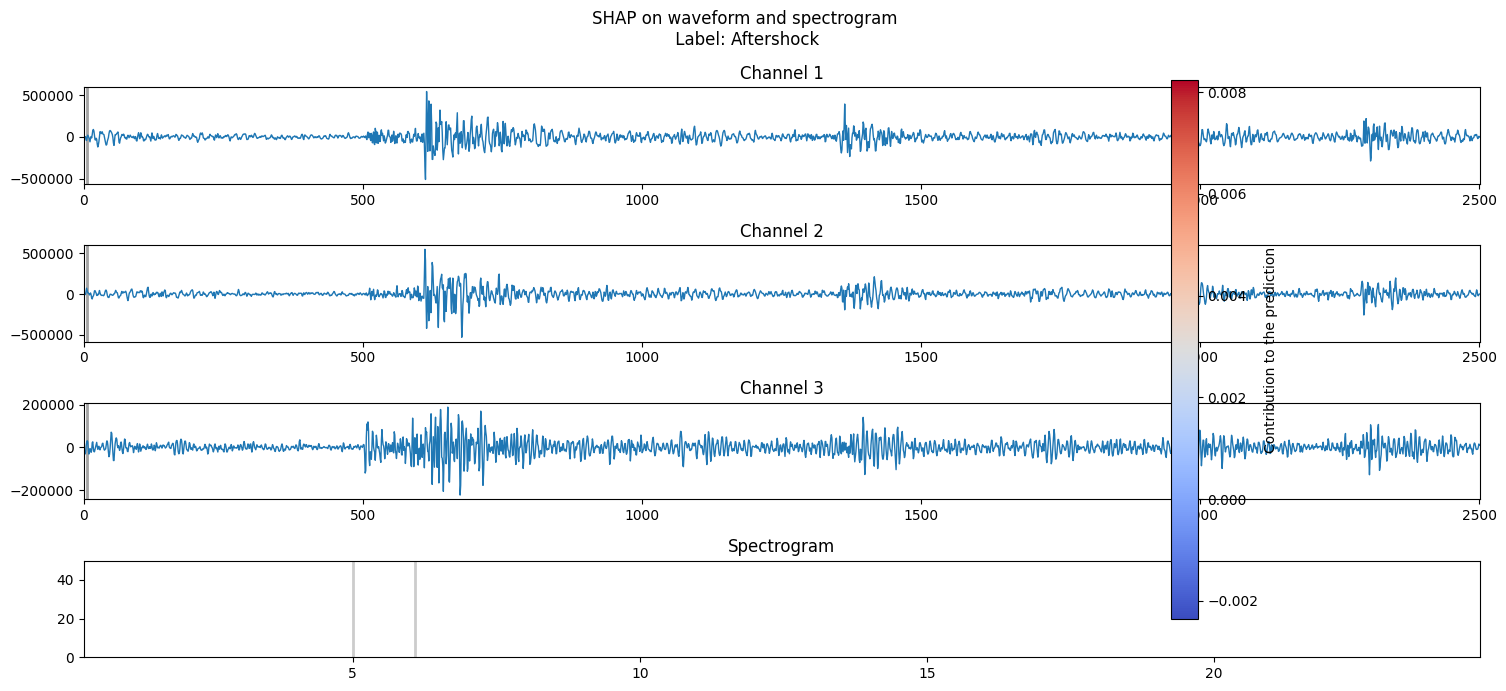

In [63]:
wf_path = r'..\dset'
shap_path = r'temporal_shap'
file_dir = os.listdir(shap_path)
file_names = [f for f in file_dir if f.endswith('EV.png.npy')]

alpha_min, alpha_max = np.inf, -np.inf

for f in file_names:
    shap_tensor = np.load(os.path.join(shap_path, f))
    alpha_min = min(alpha_min, shap_tensor.min())
    alpha_max = max(alpha_max, shap_tensor.max())


for file in file_names:
    week = int(file.split('_')[1])
    name = (file.split('_')[2]+'_'+file.split('_')[3])[:-8]
    label = 'pre' if week <= 9 else 'post'
    
    hdf = h5py.File(f'{wf_path}/NRCA/NRCA_{label}.hdf5', 'r')
    waveform = hdf[name][:]

    #img = np.load(os.path.join(shap_path, f"p_{week}_{name}_img.npy")).squeeze(axis=0).transpose(1, 2, 0)
    #img = (img - np.min(img)) / (np.max(img) - np.min(img))
    img = np.ones((33, 188, 3))
    shap_tensor = np.load(os.path.join(shap_path, f"p_{week}_{name}.png.npy")).squeeze(axis=0)

    alt_wave = df[df['trace_name'] == name].p_s_diff_sec.values[0] + 5
    day = df[df['trace_name'] == name].trace_start_time.values[0] 

    plot_wf_shap(shap_tensor = shap_tensor, 
        spectrogram = img, 
        waveform = waveform, 
        alt_wave = alt_wave,
        ft = ft,
        alpha_min = None,
        alpha_max = None,
        label = label,
        day = day,
        spec_type = "p64_08",
        figsize = (15, 7))
    
    hdf.close()
    break

In [59]:
print(np.max(img))

2.8434193


In [49]:
wf_path = r'..\dset'
shap_path = r'temporal_shap'
file_dir = os.listdir(shap_path)
file_names = [f for f in file_dir if f.endswith('EV.png.npy')]
print(file_names)

['p_0_NRCA.IV.100589713_EV.png.npy', 'p_0_NRCA.IV.100590229_EV.png.npy', 'p_0_NRCA.IV.100590430_EV.png.npy', 'p_0_NRCA.IV.100590512_EV.png.npy', 'p_0_NRCA.IV.100590841_EV.png.npy', 'p_10_NRCA.IV.100100799_EV.png.npy', 'p_10_NRCA.IV.100100996_EV.png.npy', 'p_10_NRCA.IV.100102138_EV.png.npy', 'p_10_NRCA.IV.100103014_EV.png.npy', 'p_10_NRCA.IV.100104203_EV.png.npy', 'p_11_NRCA.IV.100154194_EV.png.npy', 'p_11_NRCA.IV.100154573_EV.png.npy', 'p_11_NRCA.IV.100155772_EV.png.npy', 'p_11_NRCA.IV.100156390_EV.png.npy', 'p_11_NRCA.IV.100156404_EV.png.npy', 'p_12_NRCA.IV.100180753_EV.png.npy', 'p_12_NRCA.IV.100182690_EV.png.npy', 'p_12_NRCA.IV.100182987_EV.png.npy', 'p_12_NRCA.IV.100183185_EV.png.npy', 'p_12_NRCA.IV.100184269_EV.png.npy', 'p_13_NRCA.IV.100247534_EV.png.npy', 'p_13_NRCA.IV.100248290_EV.png.npy', 'p_13_NRCA.IV.100250372_EV.png.npy', 'p_13_NRCA.IV.100250452_EV.png.npy', 'p_13_NRCA.IV.100250735_EV.png.npy', 'p_14_NRCA.IV.100302068_EV.png.npy', 'p_14_NRCA.IV.100304335_EV.png.npy', 'p_14